# Lab 03: DCGAN — Sharp Images with Convolutions

**Goal:** Build a DCGAN that generates sharp handwritten digits using convolutional layers.

**What you'll do:**
- See convolutions in action (what filters detect)
- Build a convolutional Generator (ConvTranspose2d — grow images)
- Build a convolutional Discriminator (Conv2d — shrink images)
- Train and compare with Linear GAN (Lab 02)
- Explore the latent space (morph between digits)
- Visualize learned filters

**Time:** ~75 minutes

---

## Part 1: Setup

In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])
dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

print(f"Dataset: {len(dataset)} images")
print(f"Batches: {len(dataloader)} per epoch")

Using device: cpu
Dataset: 60000 images
Batches: 938 per epoch


---
## Part 2: See Convolutions in Action

**Before building the DCGAN, let's see what convolutions do:**
- A Conv2d layer has multiple filters (small grids of weights)
- Each filter slides across the image detecting a different pattern
- Each filter produces one "feature map" — a map of where that pattern appears

In [2]:
# Take one real image
sample_image = dataset[0][0].unsqueeze(0)  # shape: [1, 1, 28, 28]
print(f"Input shape: {sample_image.shape}")

# Apply a conv layer with 8 filters
conv = nn.Conv2d(1, 8, kernel_size=3, padding=1)
with torch.no_grad():
    feature_maps = conv(sample_image)  # shape: [1, 8, 28, 28]

print(f"Output shape: {feature_maps.shape}")
print(f"8 filters produced 8 feature maps!")

Input shape: torch.Size([1, 1, 28, 28])
Output shape: torch.Size([1, 8, 28, 28])
8 filters produced 8 feature maps!


**Visualize: original image + 8 feature maps:**
- Each feature map highlights a different pattern
- Bright areas = filter found its pattern there
- Dark areas = pattern not present

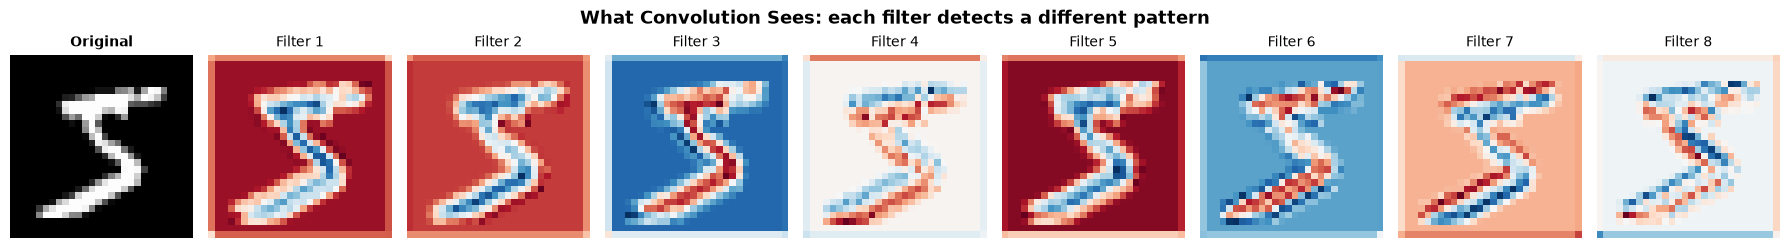

In [3]:
fig, axes = plt.subplots(1, 9, figsize=(18, 2.5))

axes[0].imshow(sample_image[0, 0], cmap='gray')
axes[0].set_title('Original', fontsize=10, fontweight='bold')
axes[0].axis('off')

for i in range(8):
    axes[i+1].imshow(feature_maps[0, i].detach(), cmap='RdBu')
    axes[i+1].set_title(f'Filter {i+1}', fontsize=10)
    axes[i+1].axis('off')

plt.suptitle('What Convolution Sees: each filter detects a different pattern',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 3: Understand the Shape Changes

**Conv2d with stride=2 HALVES the image (Discriminator uses this):**

In [4]:
print("Conv2d with stride=2 (downsampling):")
print("=" * 50)

x = torch.randn(1, 1, 28, 28)
print(f"  Input:  {x.shape}  (28x28)")

conv1 = nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1)
x1 = conv1(x)
print(f"  Conv1:  {x1.shape}  (14x14) -- halved!")

conv2 = nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1)
x2 = conv2(x1)
print(f"  Conv2:  {x2.shape}   (7x7) -- halved again!")

print(f"\n  28x28 --> 14x14 --> 7x7")
print(f"  This is what D does: shrink image to a decision")

Conv2d with stride=2 (downsampling):
  Input:  torch.Size([1, 1, 28, 28])  (28x28)
  Conv1:  torch.Size([1, 64, 14, 14])  (14x14) -- halved!
  Conv2:  torch.Size([1, 128, 7, 7])   (7x7) -- halved again!

  28x28 --> 14x14 --> 7x7
  This is what D does: shrink image to a decision


**ConvTranspose2d with stride=2 DOUBLES the image (Generator uses this):**

In [5]:
print("ConvTranspose2d with stride=2 (upsampling):")
print("=" * 50)

x = torch.randn(1, 256, 7, 7)
print(f"  Input:   {x.shape}   (7x7)")

up1 = nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1)
x1 = up1(x)
print(f"  ConvT1:  {x1.shape}  (14x14) -- doubled!")

up2 = nn.ConvTranspose2d(128, 1, kernel_size=4, stride=2, padding=1)
x2 = up2(x1)
print(f"  ConvT2:  {x2.shape}  (28x28) -- doubled again!")

print(f"\n  7x7 --> 14x14 --> 28x28")
print(f"  This is what G does: grow noise into an image")

ConvTranspose2d with stride=2 (upsampling):
  Input:   torch.Size([1, 256, 7, 7])   (7x7)
  ConvT1:  torch.Size([1, 128, 14, 14])  (14x14) -- doubled!
  ConvT2:  torch.Size([1, 1, 28, 28])  (28x28) -- doubled again!

  7x7 --> 14x14 --> 28x28
  This is what G does: grow noise into an image


**BatchNorm — keeps values stable between layers:**

In [6]:
x = torch.randn(16, 64, 7, 7) * 10 + 50  # values way out of range
bn = nn.BatchNorm2d(64)
x_normed = bn(x)

print("Before BatchNorm:")
print(f"  Mean: {x.mean():.2f}   Std: {x.std():.2f}")
print(f"  Range: [{x.min():.1f}, {x.max():.1f}]")

print(f"\nAfter BatchNorm:")
print(f"  Mean: {x_normed.mean():.2f}   Std: {x_normed.std():.2f}")
print(f"  Range: [{x_normed.min():.1f}, {x_normed.max():.1f}]")

print(f"\nBatchNorm centered and scaled the values -- stable training!")

Before BatchNorm:
  Mean: 50.10   Std: 10.01
  Range: [8.4, 91.9]

After BatchNorm:
  Mean: 0.00   Std: 1.00
  Range: [-4.1, 4.2]

BatchNorm centered and scaled the values -- stable training!


---
## Part 4: Build the DCGAN Generator

**Architecture:**
- Input: 100 random numbers (noise)
- Linear → reshape to 256 channels x 7x7 (tiny feature map)
- ConvTranspose2d (stride=2): 7x7 → 14x14 + BatchNorm + ReLU
- ConvTranspose2d (stride=2): 14x14 → 28x28 + Tanh
- Output: 1 channel x 28x28 image

**Key ideas:**
- G starts with noise and GROWS it into an image
- ConvTranspose2d doubles spatial size at each step
- BatchNorm keeps values stable between layers
- ReLU in hidden layers, Tanh at output (pixels in [-1, 1])

In [7]:
NOISE_SIZE = 100

class DCGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # Step 1: noise (100) --> 256 x 7 x 7
            nn.Linear(NOISE_SIZE, 256 * 7 * 7),
            nn.ReLU(),
            nn.Unflatten(1, (256, 7, 7)),

            # Step 2: 256x7x7 --> 128x14x14 (upsample)
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            # Step 3: 128x14x14 --> 1x28x28 (upsample to final image)
            nn.ConvTranspose2d(128, 1, kernel_size=4, stride=2, padding=1),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)

gen = DCGenerator().to(device)
print("DCGAN Generator:")
print(gen)
print(f"\nParameters: {sum(p.numel() for p in gen.parameters()):,}")

DCGAN Generator:
DCGenerator(
  (net): Sequential(
    (0): Linear(in_features=100, out_features=12544, bias=True)
    (1): ReLU()
    (2): Unflatten(dim=1, unflattened_size=(256, 7, 7))
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): ConvTranspose2d(128, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): Tanh()
  )
)

Parameters: 1,793,665


**Trace the shapes through G step by step:**
- Watch how the data grows from 100 numbers to a 28x28 image
- Each ConvTranspose2d doubles the spatial size

In [8]:
print("Shape trace through Generator:")
print("=" * 50)

z = torch.randn(1, NOISE_SIZE, device=device)
print(f"  Input noise:              {z.shape}")

x = gen.net[0](z)  # Linear
print(f"  After Linear(100->12544): {x.shape}")
x = gen.net[1](x)  # ReLU
x = gen.net[2](x)  # Unflatten
print(f"  After Unflatten:          {x.shape}")
x = gen.net[3](x)  # ConvTranspose
print(f"  After ConvT (7->14):      {x.shape}")
x = gen.net[4](x)  # BatchNorm
x = gen.net[5](x)  # ReLU
x = gen.net[6](x)  # ConvTranspose
print(f"  After ConvT (14->28):     {x.shape}")
x = gen.net[7](x)  # Tanh
print(f"  After Tanh:               {x.shape}")
print(f"\n  100 numbers --> 28x28 image!")

Shape trace through Generator:
  Input noise:              torch.Size([1, 100])
  After Linear(100->12544): torch.Size([1, 12544])
  After Unflatten:          torch.Size([1, 256, 7, 7])
  After ConvT (7->14):      torch.Size([1, 128, 14, 14])
  After ConvT (14->28):     torch.Size([1, 1, 28, 28])
  After Tanh:               torch.Size([1, 1, 28, 28])

  100 numbers --> 28x28 image!


---
## Part 5: Build the DCGAN Discriminator

**Architecture (mirror of G):**
- Input: 1 channel x 28x28 image
- Conv2d (stride=2): 28x28 → 14x14 + LeakyReLU (NO BatchNorm in first layer)
- Conv2d (stride=2): 14x14 → 7x7 + BatchNorm + LeakyReLU
- Flatten → Linear → Sigmoid
- Output: probability (0 = fake, 1 = real)

**Key ideas:**
- D takes an image and SHRINKS it to one answer
- Conv2d halves spatial size at each step
- LeakyReLU(0.2) keeps gradients alive (20% of negatives pass through)
- No BatchNorm in first layer — D needs to see raw pixel values

In [9]:
class DCDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # Step 1: 1x28x28 --> 64x14x14 (downsample)
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            # No BatchNorm here (DCGAN rule)

            # Step 2: 64x14x14 --> 128x7x7 (downsample)
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            # Step 3: flatten and classify
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        return self.net(img)

dis = DCDiscriminator().to(device)
print("DCGAN Discriminator:")
print(dis)
print(f"\nParameters: {sum(p.numel() for p in dis.parameters()):,}")

DCGAN Discriminator:
DCDiscriminator(
  (net): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Flatten(start_dim=1, end_dim=-1)
    (6): Linear(in_features=6272, out_features=1, bias=True)
    (7): Sigmoid()
  )
)

Parameters: 138,817


**Trace shapes through D:**
- Watch the image shrink from 28x28 to a single probability

In [10]:
print("Shape trace through Discriminator:")
print("=" * 50)

img = torch.randn(1, 1, 28, 28, device=device)
print(f"  Input image:          {img.shape}")

x = dis.net[0](img)
print(f"  After Conv (28->14):  {x.shape}")
x = dis.net[1](x)    # LeakyReLU
x = dis.net[2](x)    # Conv
print(f"  After Conv (14->7):   {x.shape}")
x = dis.net[3](x)    # BN
x = dis.net[4](x)    # LeakyReLU
x = dis.net[5](x)    # Flatten
print(f"  After Flatten:        {x.shape}")
x = dis.net[6](x)    # Linear
x = dis.net[7](x)    # Sigmoid
print(f"  After Sigmoid:        {x.shape}")
print(f"\n  28x28 image --> 1 probability!")

Shape trace through Discriminator:
  Input image:          torch.Size([1, 1, 28, 28])
  After Conv (28->14):  torch.Size([1, 64, 14, 14])
  After Conv (14->7):   torch.Size([1, 128, 7, 7])
  After Flatten:        torch.Size([1, 6272])
  After Sigmoid:        torch.Size([1, 1])

  28x28 image --> 1 probability!


---
## Part 6: Weight Initialization

**DCGAN paper recommends:**
- Initialize all weights from Normal(mean=0, std=0.02)
- Good starting weights → smooth training from the start
- Bad starting weights → gradients explode or vanish immediately

In [11]:
def weights_init(m):
    classname = m.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)
    elif 'Linear' in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)

gen.apply(weights_init)
dis.apply(weights_init)
print("Weights initialized: Normal(0, 0.02)")

Weights initialized: Normal(0, 0.02)


---
## Part 7: Train the DCGAN

**Same training loop as Lab 02!**
- Step A: train D (real + fake, .detach())
- Step B: train G (fool D, no .detach())
- Only difference: images stay as 2D (no flattening needed)

**DCGAN settings:**
- Adam with lr=0.0002, betas=(0.5, 0.999)
- betas=(0.5, 0.999) = less momentum than default, better for GANs

**What to watch:**
- Images should be MUCH sharper than Lab 02
- D(real) and D(fake) scores — ideally both near 0.5

In [12]:
loss_fn = nn.BCELoss()
gen_opt = torch.optim.Adam(gen.parameters(), lr=0.0002, betas=(0.5, 0.999))
dis_opt = torch.optim.Adam(dis.parameters(), lr=0.0002, betas=(0.5, 0.999))

fixed_noise = torch.randn(16, NOISE_SIZE, device=device)

print("Optimizer: Adam(lr=0.0002, betas=(0.5, 0.999))")
print("This is the DCGAN paper's recommended setting.")

Optimizer: Adam(lr=0.0002, betas=(0.5, 0.999))
This is the DCGAN paper's recommended setting.


In [13]:
def show_progress(generator, noise, epoch):
    generator.eval()
    with torch.no_grad():
        imgs = generator(noise).cpu()
    generator.train()

    fig, axes = plt.subplots(2, 8, figsize=(14, 3.5))
    for i, ax in enumerate(axes.flat):
        ax.imshow(imgs[i, 0], cmap='gray', vmin=-1, vmax=1)
        ax.axis('off')
    plt.suptitle(f'Epoch {epoch}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

Training DCGAN for 20 epochs...


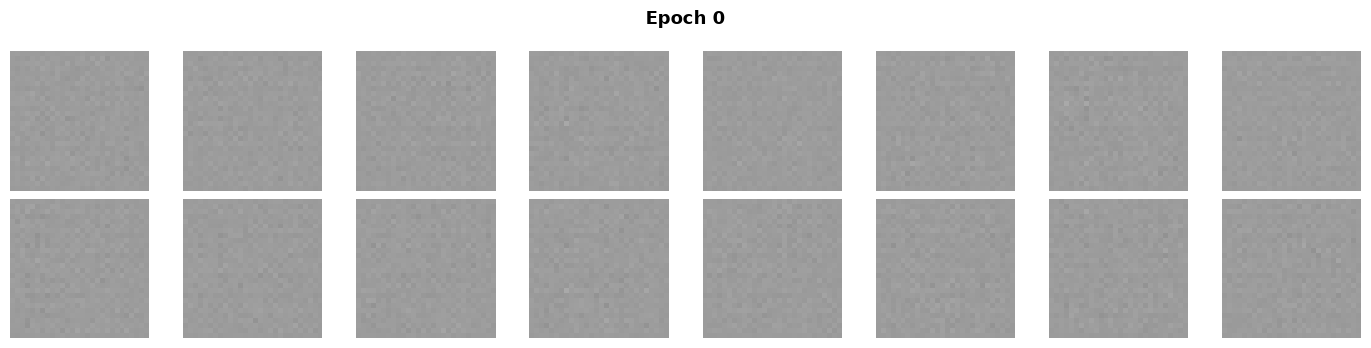

Epoch  1: D_loss=0.7406  G_loss=1.7265  D(real)=0.722  D(fake)=0.255


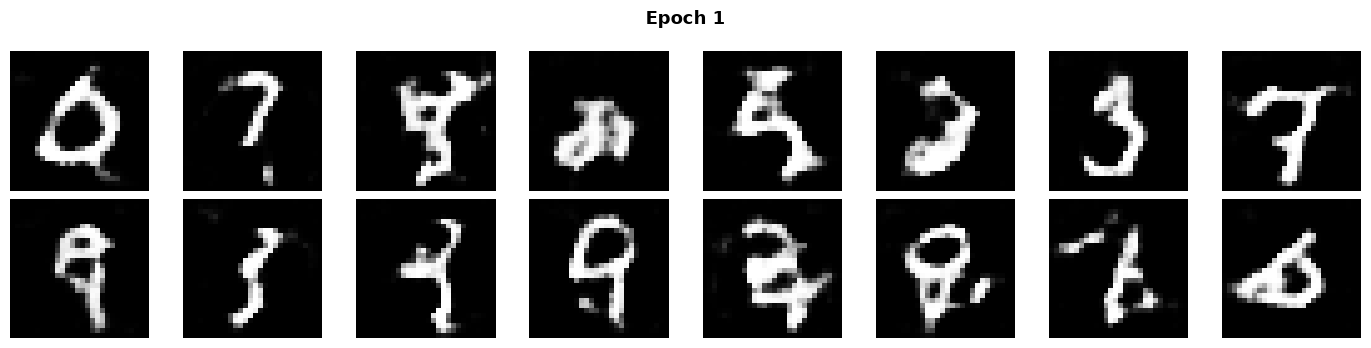

Epoch  2: D_loss=0.8605  G_loss=1.3686  D(real)=0.685  D(fake)=0.310
Epoch  3: D_loss=0.8460  G_loss=1.4097  D(real)=0.692  D(fake)=0.301
Epoch  4: D_loss=0.8382  G_loss=1.4470  D(real)=0.697  D(fake)=0.296
Epoch  5: D_loss=0.8266  G_loss=1.4761  D(real)=0.701  D(fake)=0.291


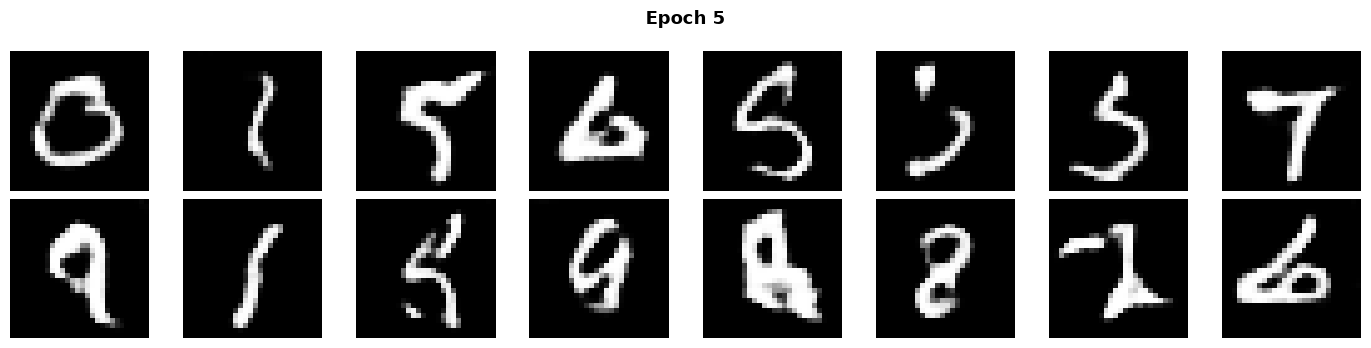

Epoch  6: D_loss=0.8283  G_loss=1.4941  D(real)=0.703  D(fake)=0.290
Epoch  7: D_loss=0.8333  G_loss=1.5136  D(real)=0.703  D(fake)=0.290
Epoch  8: D_loss=0.8401  G_loss=1.5118  D(real)=0.702  D(fake)=0.291
Epoch  9: D_loss=0.8335  G_loss=1.5311  D(real)=0.705  D(fake)=0.288
Epoch 10: D_loss=0.8440  G_loss=1.5332  D(real)=0.703  D(fake)=0.290


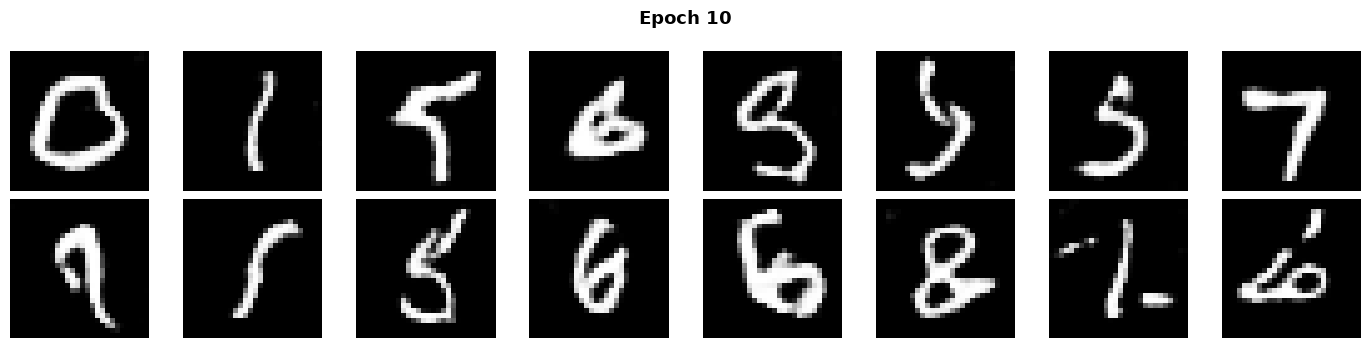

Epoch 11: D_loss=0.8305  G_loss=1.5653  D(real)=0.707  D(fake)=0.285
Epoch 12: D_loss=0.8266  G_loss=1.5780  D(real)=0.708  D(fake)=0.283
Epoch 13: D_loss=0.8237  G_loss=1.5561  D(real)=0.708  D(fake)=0.289
Epoch 14: D_loss=0.8169  G_loss=1.5908  D(real)=0.711  D(fake)=0.283
Epoch 15: D_loss=0.8231  G_loss=1.6051  D(real)=0.710  D(fake)=0.282


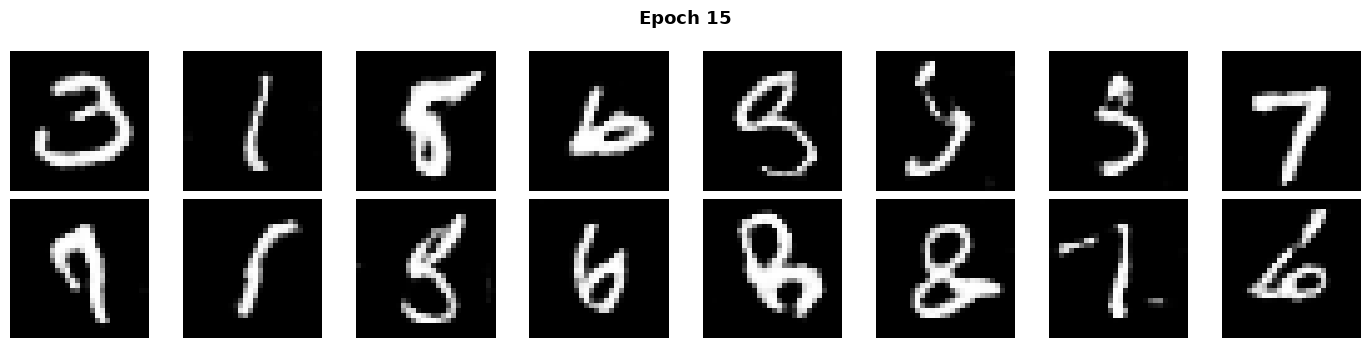

Epoch 16: D_loss=0.8185  G_loss=1.6039  D(real)=0.711  D(fake)=0.284
Epoch 17: D_loss=0.8157  G_loss=1.6040  D(real)=0.713  D(fake)=0.282
Epoch 18: D_loss=0.8181  G_loss=1.6218  D(real)=0.712  D(fake)=0.279
Epoch 19: D_loss=0.8236  G_loss=1.6217  D(real)=0.712  D(fake)=0.282
Epoch 20: D_loss=0.8119  G_loss=1.6340  D(real)=0.714  D(fake)=0.277


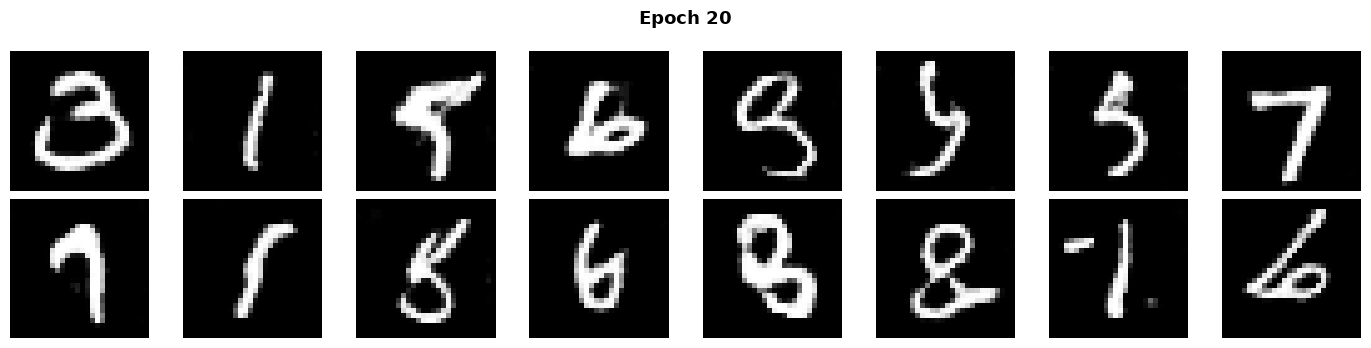


Training complete!


In [14]:
num_epochs = 20
gen_losses = []
dis_losses = []
d_real_scores = []
d_fake_scores = []

print(f"Training DCGAN for {num_epochs} epochs...")
print("=" * 60)

show_progress(gen, fixed_noise, epoch=0)

for epoch in range(1, num_epochs + 1):
    eg, ed, edr, edf, nb = 0, 0, 0, 0, 0

    for real_images, _ in dataloader:
        batch_size = real_images.size(0)
        real_images = real_images.to(device)       # keep as 2D! no flatten!
        real_labels = torch.ones(batch_size, 1, device=device)
        fake_labels = torch.zeros(batch_size, 1, device=device)

        # ====== Step A: Train D ======
        real_pred = dis(real_images)
        loss_real = loss_fn(real_pred, real_labels)

        noise = torch.randn(batch_size, NOISE_SIZE, device=device)
        fake_images = gen(noise).detach()
        fake_pred = dis(fake_images)
        loss_fake = loss_fn(fake_pred, fake_labels)

        dis_loss = loss_real + loss_fake
        dis_opt.zero_grad()
        dis_loss.backward()
        dis_opt.step()

        # ====== Step B: Train G ======
        noise = torch.randn(batch_size, NOISE_SIZE, device=device)
        fake_images = gen(noise)
        fake_pred = dis(fake_images)
        gen_loss = loss_fn(fake_pred, real_labels)

        gen_opt.zero_grad()
        gen_loss.backward()
        gen_opt.step()

        eg += gen_loss.item()
        ed += dis_loss.item()
        edr += real_pred.mean().item()
        edf += fake_pred.mean().item()
        nb += 1

    gen_losses.append(eg / nb)
    dis_losses.append(ed / nb)
    d_real_scores.append(edr / nb)
    d_fake_scores.append(edf / nb)

    print(f"Epoch {epoch:2d}: D_loss={dis_losses[-1]:.4f}  G_loss={gen_losses[-1]:.4f}  "
          f"D(real)={d_real_scores[-1]:.3f}  D(fake)={d_fake_scores[-1]:.3f}")

    if epoch in [1, 5, 10, 15, 20]:
        show_progress(gen, fixed_noise, epoch)

print("\nTraining complete!")

---
## Part 8: Training Analysis

**Three plots to understand training:**
- Losses: should stay in similar range (neither drops to 0)
- D scores: D(real) and D(fake) both near 0.5 = G fooled D
- Loss ratio: ideally around 1.0 (balanced)

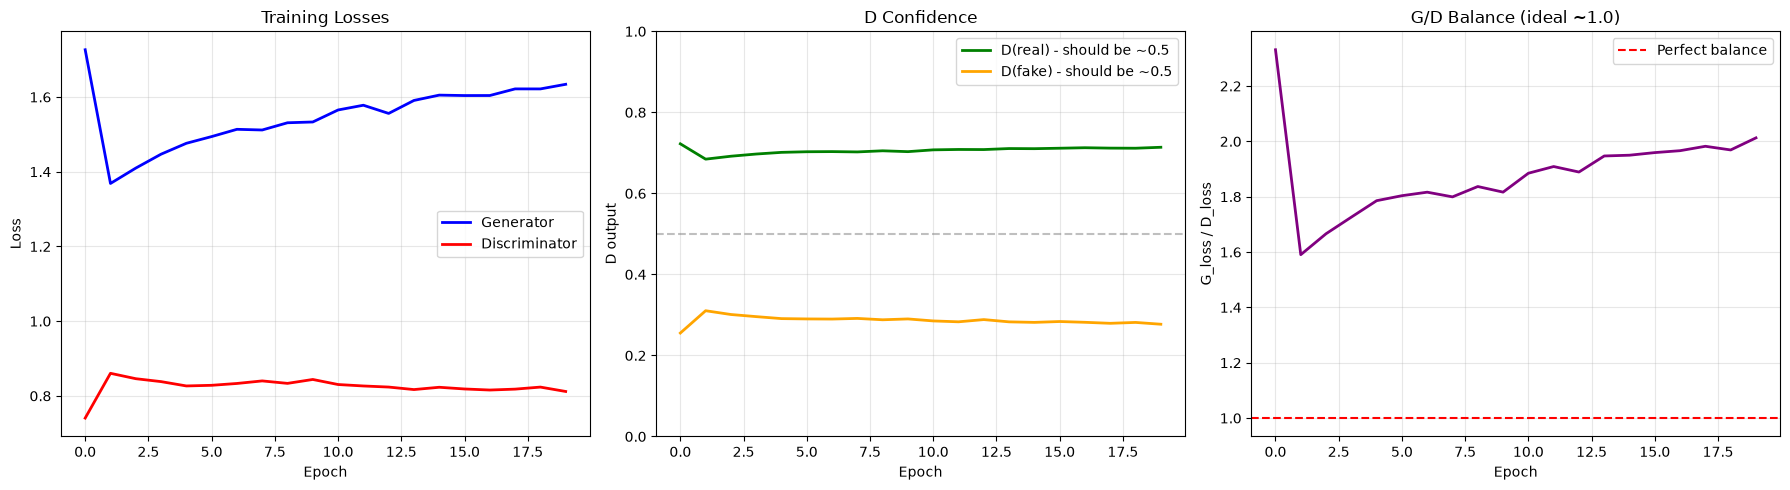

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(gen_losses, label='Generator', color='blue', linewidth=2)
axes[0].plot(dis_losses, label='Discriminator', color='red', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Losses')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(d_real_scores, label='D(real) - should be ~0.5', color='green', linewidth=2)
axes[1].plot(d_fake_scores, label='D(fake) - should be ~0.5', color='orange', linewidth=2)
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('D output')
axes[1].set_title('D Confidence')
axes[1].legend()
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)

ratio = [g / (d + 1e-8) for g, d in zip(gen_losses, dis_losses)]
axes[2].plot(ratio, color='purple', linewidth=2)
axes[2].axhline(y=1.0, color='red', linestyle='--', label='Perfect balance')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('G_loss / D_loss')
axes[2].set_title('G/D Balance (ideal ~1.0)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Part 9: Final Results — Big Grid

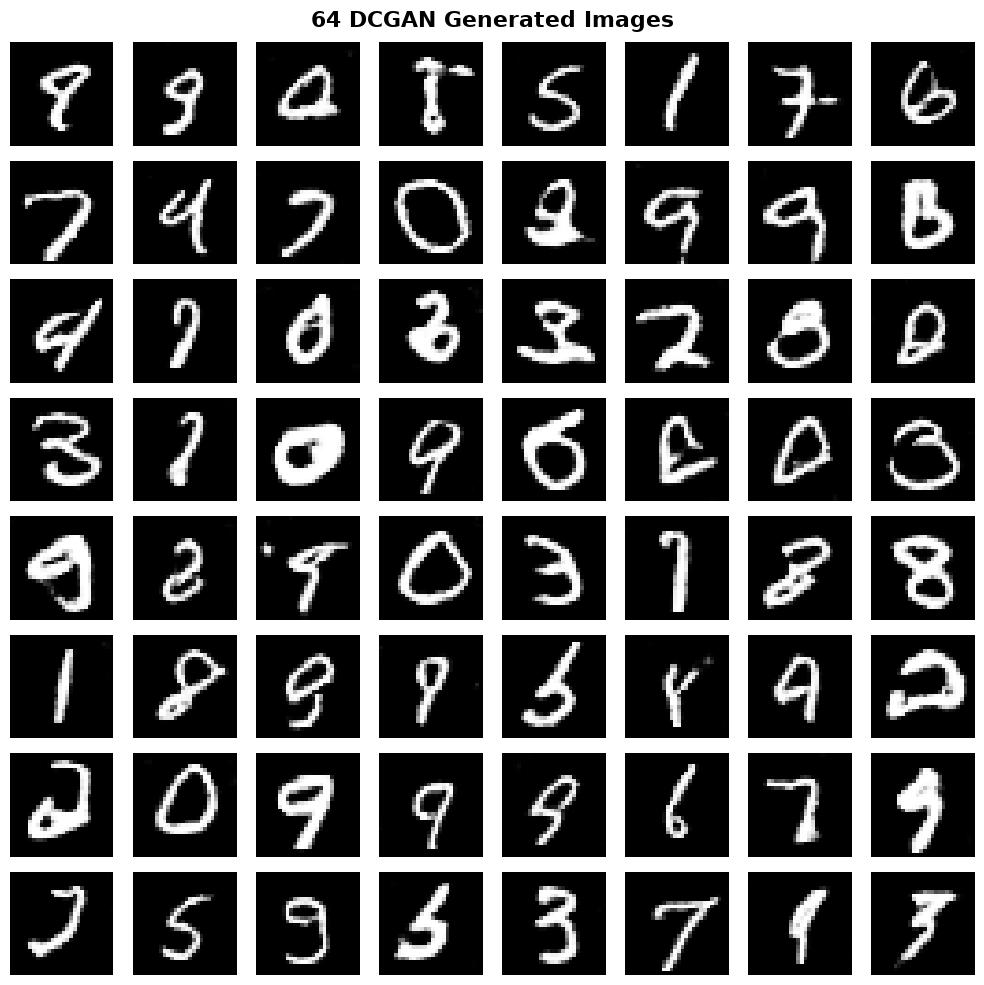

In [16]:
gen.eval()
with torch.no_grad():
    noise = torch.randn(64, NOISE_SIZE, device=device)
    generated = gen(noise).cpu()

fig, axes = plt.subplots(8, 8, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i, 0], cmap='gray', vmin=-1, vmax=1)
    ax.axis('off')

plt.suptitle('64 DCGAN Generated Images', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 10: DCGAN vs Linear GAN — The Comparison

**Let's train a Linear GAN (from Lab 02) for the same epochs and compare:**
- Same training data, same number of epochs
- Only difference: architecture (Linear vs Conv)

In [17]:
# Quick Linear GAN for comparison
lin_gen = nn.Sequential(
    nn.Linear(100, 256), nn.ReLU(),
    nn.Linear(256, 512), nn.ReLU(),
    nn.Linear(512, 784), nn.Tanh()
).to(device)

lin_dis = nn.Sequential(
    nn.Linear(784, 512), nn.LeakyReLU(0.2),
    nn.Linear(512, 256), nn.LeakyReLU(0.2),
    nn.Linear(256, 1), nn.Sigmoid()
).to(device)

lin_g_opt = torch.optim.Adam(lin_gen.parameters(), lr=0.0002)
lin_d_opt = torch.optim.Adam(lin_dis.parameters(), lr=0.0002)

print(f"Linear GAN params:  G={sum(p.numel() for p in lin_gen.parameters()):,}  "
      f"D={sum(p.numel() for p in lin_dis.parameters()):,}")
print(f"DCGAN params:       G={sum(p.numel() for p in gen.parameters()):,}  "
      f"D={sum(p.numel() for p in dis.parameters()):,}")

print(f"\nTraining Linear GAN for {num_epochs} epochs...")
for epoch in range(1, num_epochs + 1):
    for real_imgs, _ in dataloader:
        bs = real_imgs.size(0)
        real = real_imgs.view(bs, -1).to(device)
        ones = torch.ones(bs, 1, device=device)
        zeros = torch.zeros(bs, 1, device=device)

        d_loss = loss_fn(lin_dis(real), ones) + \
                 loss_fn(lin_dis(lin_gen(torch.randn(bs, 100, device=device)).detach()), zeros)
        lin_d_opt.zero_grad(); d_loss.backward(); lin_d_opt.step()

        g_loss = loss_fn(lin_dis(lin_gen(torch.randn(bs, 100, device=device))), ones)
        lin_g_opt.zero_grad(); g_loss.backward(); lin_g_opt.step()

    if epoch % 5 == 0:
        print(f"  Epoch {epoch}")

print("Done!")

Linear GAN params:  G=559,632  D=533,505
DCGAN params:       G=1,793,665  D=138,817

Training Linear GAN for 20 epochs...
  Epoch 5
  Epoch 10
  Epoch 15
  Epoch 20
Done!


**Side by side: Real vs Linear GAN vs DCGAN:**
- Top: real MNIST images
- Middle: Linear GAN (from Lab 02) — blurry
- Bottom: DCGAN — sharp!

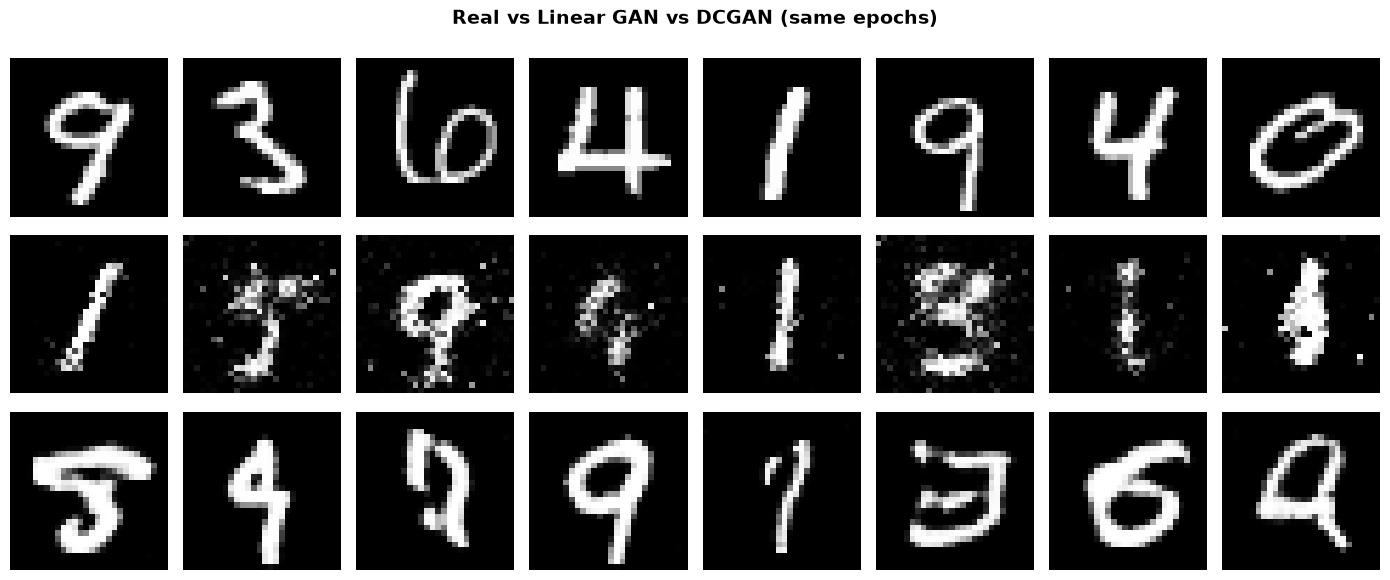

DCGAN is MUCH sharper because convolutions understand spatial structure.
Linear GAN treats each pixel independently -- no concept of neighbors.


In [19]:
fig, axes = plt.subplots(3, 8, figsize=(14, 6))

# Row 1: Real
real_batch = next(iter(dataloader))[0]
for i in range(8):
    axes[0, i].imshow(real_batch[i, 0], cmap='gray')
    axes[0, i].axis('off')
axes[0, 0].set_ylabel('REAL', fontsize=12, fontweight='bold', rotation=0, labelpad=55)

# Row 2: Linear GAN
lin_gen.eval()
with torch.no_grad():
    lin_imgs = lin_gen(torch.randn(8, 100, device=device)).cpu().view(-1, 28, 28)
for i in range(8):
    axes[1, i].imshow(lin_imgs[i], cmap='gray', vmin=-1, vmax=1)
    axes[1, i].axis('off')
axes[1, 0].set_ylabel('Linear\nGAN', fontsize=12, fontweight='bold', rotation=0, labelpad=55)

# Row 3: DCGAN
gen.eval()
with torch.no_grad():
    dc_imgs = gen(torch.randn(8, 100, device=device)).cpu()
for i in range(8):
    axes[2, i].imshow(dc_imgs[i, 0], cmap='gray', vmin=-1, vmax=1)
    axes[2, i].axis('off')
axes[2, 0].set_ylabel('DCGAN', fontsize=12, fontweight='bold', rotation=0, labelpad=55)

plt.suptitle('Real vs Linear GAN vs DCGAN (same epochs)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("DCGAN is MUCH sharper because convolutions understand spatial structure.")
print("Linear GAN treats each pixel independently -- no concept of neighbors.")

---
## Part 11: Latent Space Exploration

**The noise vector is G's "imagination space" (latent space).**
- Each point in this space maps to a different image
- Nearby points → similar images
- Smooth walk between two points → smooth morph between images

### Interpolation — morph between two images

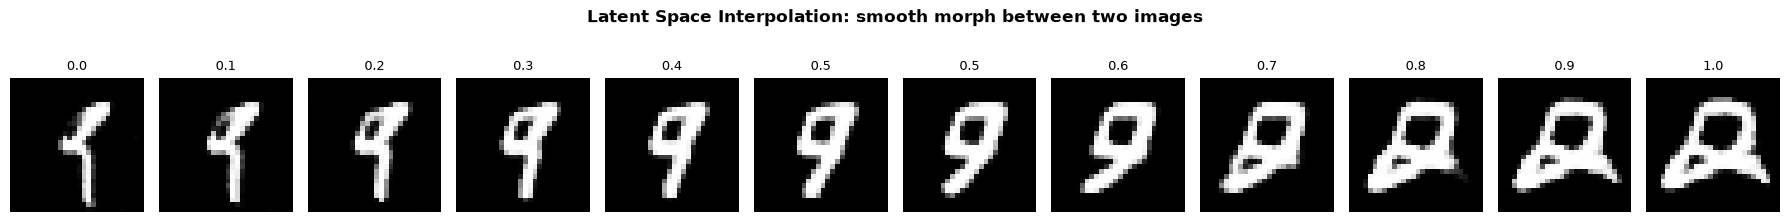

Smooth transitions = G learned a structured, continuous mapping.
No jumps or glitches = the latent space is well organized.


In [20]:
gen.eval()

with torch.no_grad():
    z1 = torch.randn(1, NOISE_SIZE, device=device)
    z2 = torch.randn(1, NOISE_SIZE, device=device)

    steps = 12
    fig, axes = plt.subplots(1, steps, figsize=(18, 2.5))

    for i, ax in enumerate(axes):
        alpha = i / (steps - 1)                   # 0.0 to 1.0
        z = (1 - alpha) * z1 + alpha * z2         # blend z1 and z2
        img = gen(z).cpu()
        ax.imshow(img[0, 0], cmap='gray', vmin=-1, vmax=1)
        ax.set_title(f'{alpha:.1f}', fontsize=9)
        ax.axis('off')

    plt.suptitle('Latent Space Interpolation: smooth morph between two images',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("Smooth transitions = G learned a structured, continuous mapping.")
print("No jumps or glitches = the latent space is well organized.")

### Multiple interpolation paths

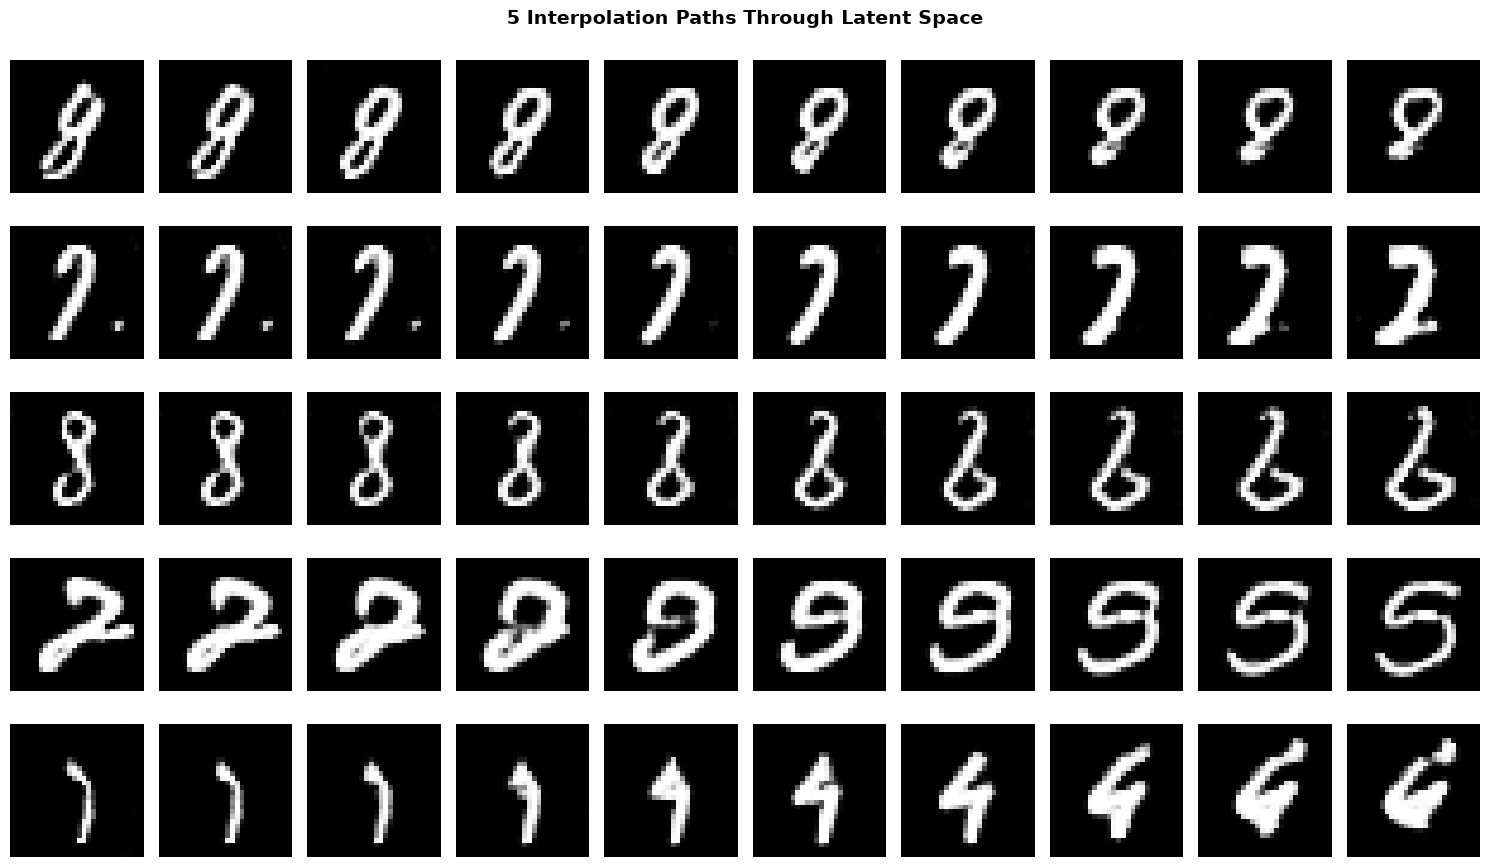

In [21]:
num_paths = 5
steps = 10

fig, axes = plt.subplots(num_paths, steps, figsize=(15, num_paths * 1.8))

with torch.no_grad():
    for row in range(num_paths):
        z1 = torch.randn(1, NOISE_SIZE, device=device)
        z2 = torch.randn(1, NOISE_SIZE, device=device)

        for col in range(steps):
            alpha = col / (steps - 1)
            z = (1 - alpha) * z1 + alpha * z2
            img = gen(z).cpu()
            axes[row, col].imshow(img[0, 0], cmap='gray', vmin=-1, vmax=1)
            axes[row, col].axis('off')

plt.suptitle('5 Interpolation Paths Through Latent Space',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 12: Visualize Learned Filters

**D's first layer filters — what did the network learn to look for?**
- Each small grid is one 4x4 filter
- The network figured out these patterns on its own
- Common patterns: edges, gradients, corners

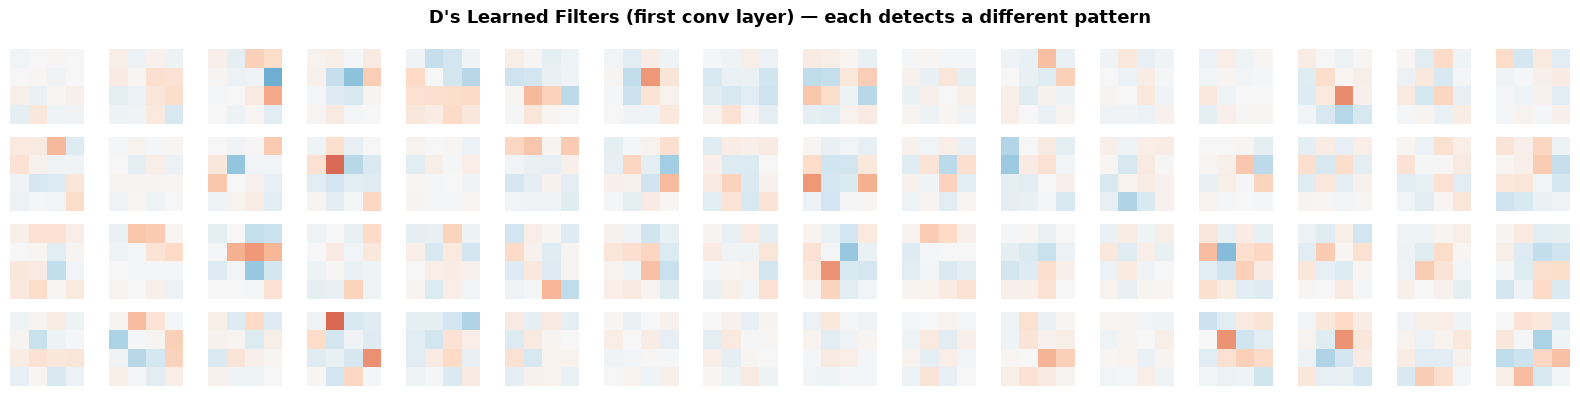

Each 4x4 grid = one filter the network learned.
These detect edges, gradients, corners, textures...
The network figured these out on its own through training!


In [22]:
filters = dis.net[0].weight.data.cpu()  # shape: [64, 1, 4, 4]

fig, axes = plt.subplots(4, 16, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(filters[i, 0], cmap='RdBu', vmin=-0.3, vmax=0.3)
    ax.axis('off')

plt.suptitle("D's Learned Filters (first conv layer) — each detects a different pattern",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Each 4x4 grid = one filter the network learned.")
print("These detect edges, gradients, corners, textures...")
print("The network figured these out on its own through training!")

---
## Part 13: Summary

| What you did | What it means |
|---|---|
| Saw convolutions in action | Filters detect patterns (edges, shapes) |
| Built DCGenerator | ConvTranspose2d grows: 7→14→28 |
| Built DCDiscriminator | Conv2d shrinks: 28→14→7 |
| Weight init N(0, 0.02) | Smooth training start |
| Adam betas=(0.5, 0.999) | Less momentum, better for GANs |
| No flattening needed | Images stay as 2D throughout |
| DCGAN >> Linear GAN | Convolutions understand spatial structure |
| Latent interpolation | Smooth walk = well-organized latent space |
| Learned filters | Network discovers its own pattern detectors |

**The journey so far:**
```
Lab 01: GAN for 1 number      → works (trivial)
Lab 02: Linear GAN for images  → works but blurry
Lab 03: DCGAN for images       → sharp images!
```

**Next lab:** GAN training can go wrong in many ways. Lab 04 teaches you to **break training on purpose** and **fix it** with tricks.